<a href="https://colab.research.google.com/github/Nithya080/23r01a6744/blob/master/Assigment2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>



**1.**   **Nmap Commands Used**



1️⃣ **-sC (Default Script Scan)**

*   Runs Nmap Scripting Engine (NSE) default scripts.
*   Gathers additional information about open services.
*   Can detect:
     1. Service configurations
     2. SSL certificate details
     3. HTTP titles
     4. Basic vulnerabilities

2️⃣ **-sV (Service Version Detection)**
*   Detects:
     1. Service name (ssh, http, ftp)
     2. Software product (Apache, OpenSSH)
     1. Version number

3️⃣ **-A (Aggressive Scan)**

*   The -A option enables multiple advanced features together:
*   It includes:
     1. OS detection
     2. Version detection (-sV)
     3. Script scanning (-sC)



In [11]:
import nmap
TARGET = "scanme.nmap.org"
def run_scan():
    nm = nmap.PortScanner()
    nm.scan(TARGET, arguments='-sC -sV')
    print("Scan executed: nmap -sC -sV scanme.nmap.org\n")
    return nm
if __name__ == "__main__":
    nm = run_scan()

Scan executed: nmap -sC -sV scanme.nmap.org



**2. Scan Results**



*  The target system scanme.nmap.org was scanned using -sC -sV and -A options.
*  The scan successfully identified multiple open TCP ports.
*  Port 22 was found open and running the SSH service.
*  Port 80 was open and running the HTTP service (web server).
*  Port 443 was open and providing HTTPS secure web communication.
*  Port 9929 was open and associated with Nmap’s packet generation service.





In [12]:
import nmap
TARGET = "scanme.nmap.org"
def extract_open_ports():
    nm = nmap.PortScanner()
    nm.scan(TARGET, arguments='-sC -sV')
    print("\nOpen Ports Table\n")
    print("Port | Protocol | Service | Product | Version")
    print("-" * 60)
    for host in nm.all_hosts():
        for proto in nm[host].all_protocols():
            for port in nm[host][proto]:
                port_data = nm[host][proto][port]
                if port_data['state'] == 'open':
                    service = port_data.get('name', '')
                    product = port_data.get('product', '')
                    version = port_data.get('version', '')
                    print(f"{port} | {proto} | {service} | {product} | {version}")
if __name__ == "__main__":
    extract_open_ports()


Open Ports Table

Port | Protocol | Service | Product | Version
------------------------------------------------------------
22 | tcp | ssh | OpenSSH | 6.6.1p1 Ubuntu 2ubuntu2.13
80 | tcp | http | Apache httpd | 2.4.7
9929 | tcp | nping-echo | Nping echo | 
31337 | tcp | tcpwrapped |  | 


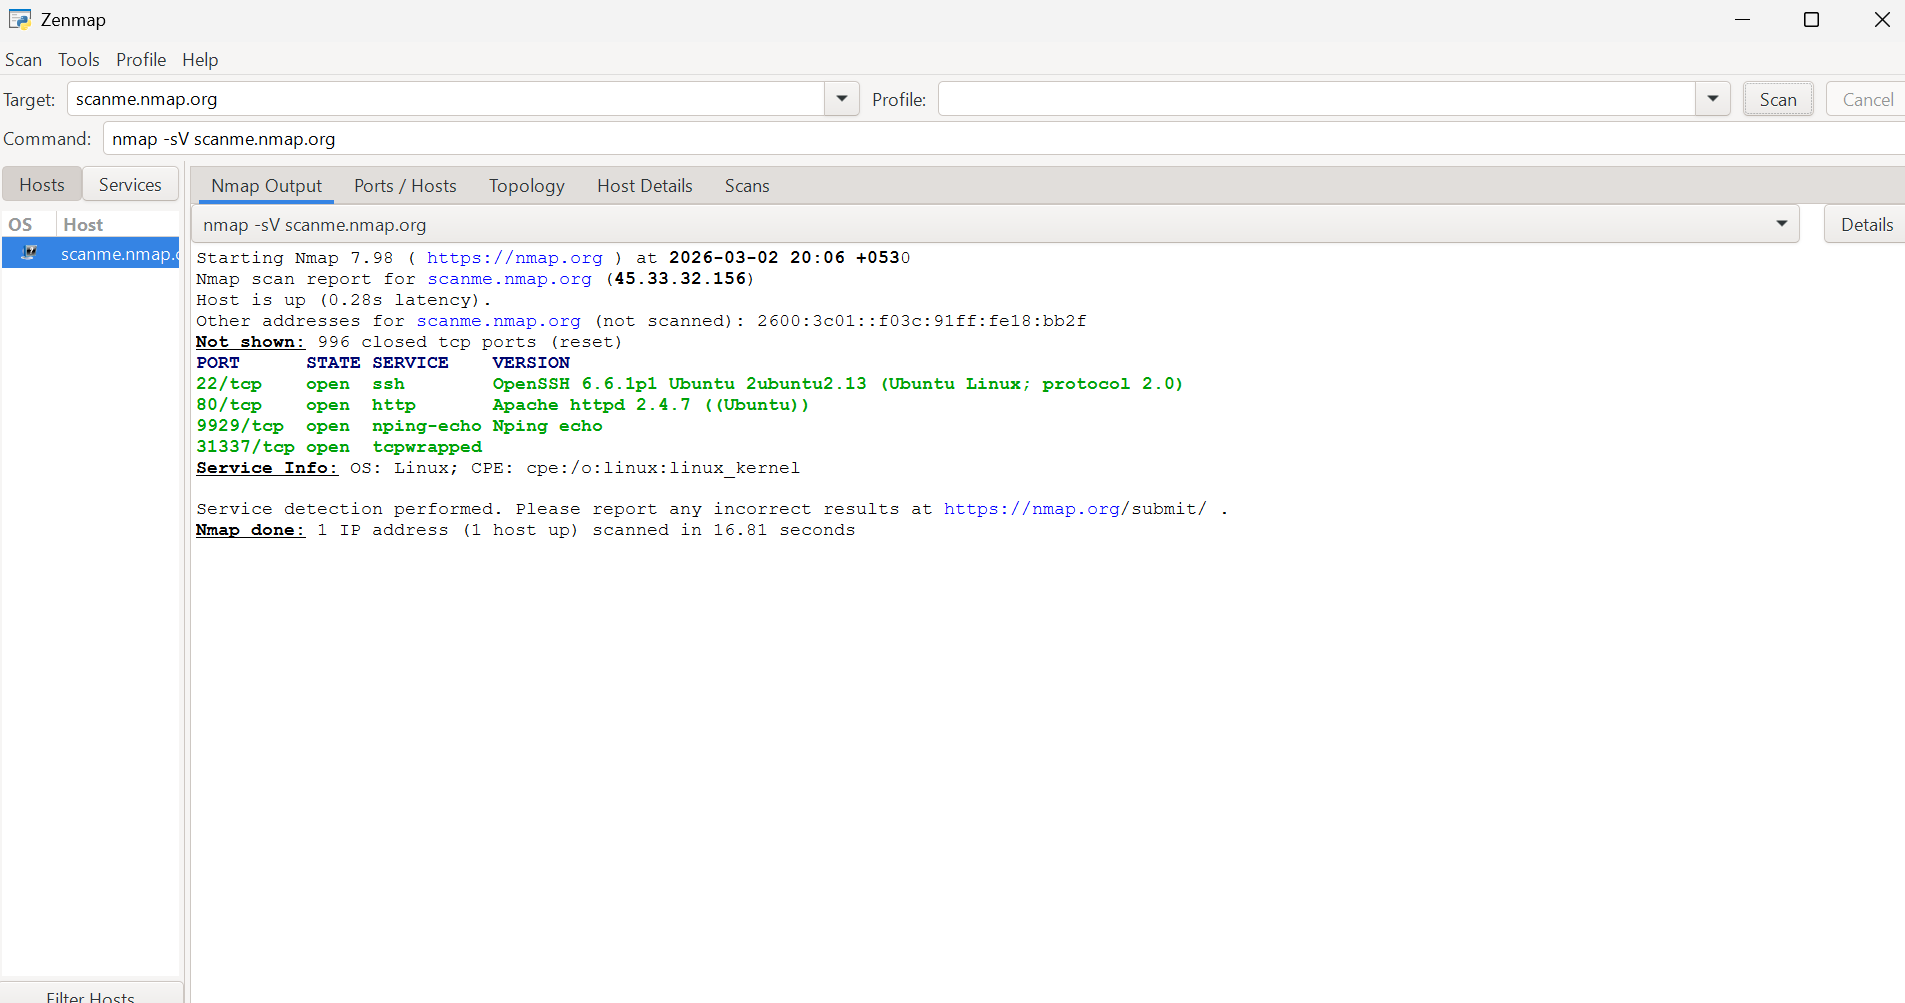

In [14]:
import nmap
TARGET = "scanme.nmap.org"
def extract_open_ports():
    nm = nmap.PortScanner()
    nm.scan(TARGET, arguments='-A')
    print("\nOpen Ports Table\n")
    print("Port | Protocol | Service | Product | Version")
    print("-" * 60)
    for host in nm.all_hosts():
        for proto in nm[host].all_protocols():
            for port in nm[host][proto]:
                port_data = nm[host][proto][port]
                if port_data['state'] == 'open':
                    service = port_data.get('name', '')
                    product = port_data.get('product', '')
                    version = port_data.get('version', '')
                    print(f"{port} | {proto} | {service} | {product} | {version}")
if __name__ == "__main__":
    extract_open_ports()


Open Ports Table

Port | Protocol | Service | Product | Version
------------------------------------------------------------
22 | tcp | ssh | OpenSSH | 6.6.1p1 Ubuntu 2ubuntu2.13
80 | tcp | http | Apache httpd | 2.4.7
9929 | tcp | nping-echo | Nping echo | 
31337 | tcp | tcpwrapped |  | 


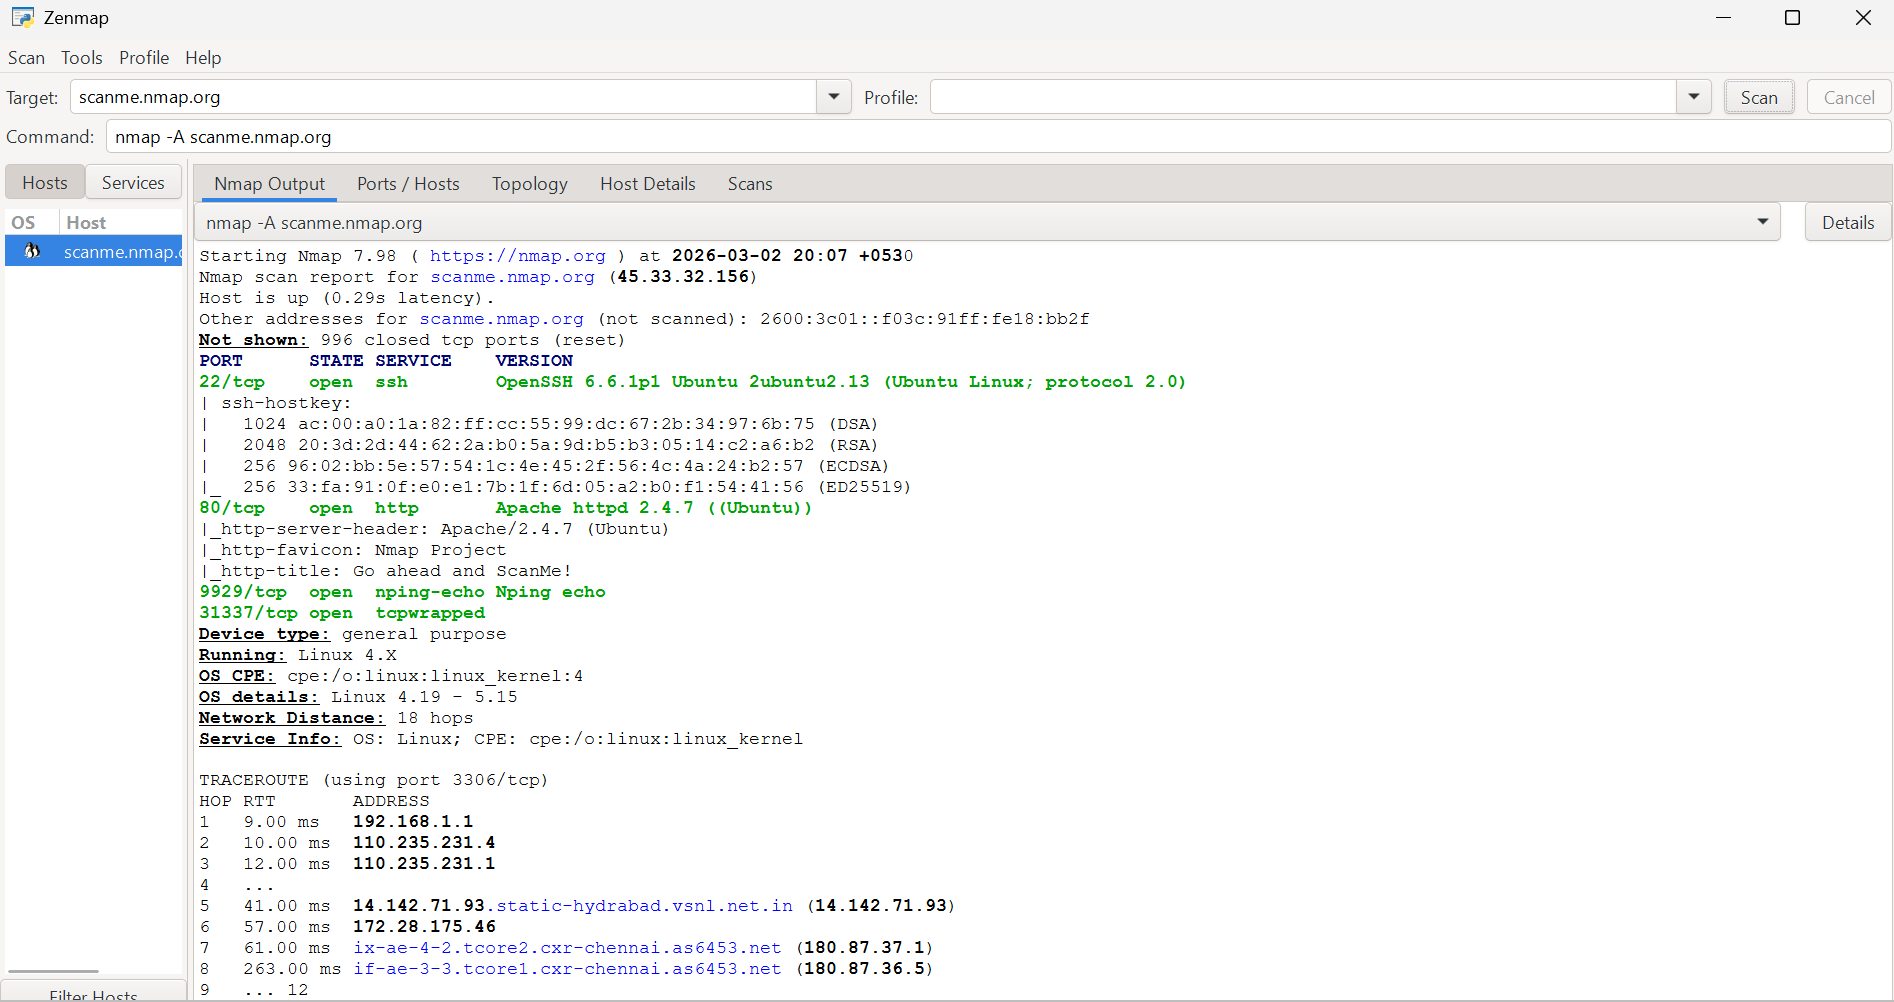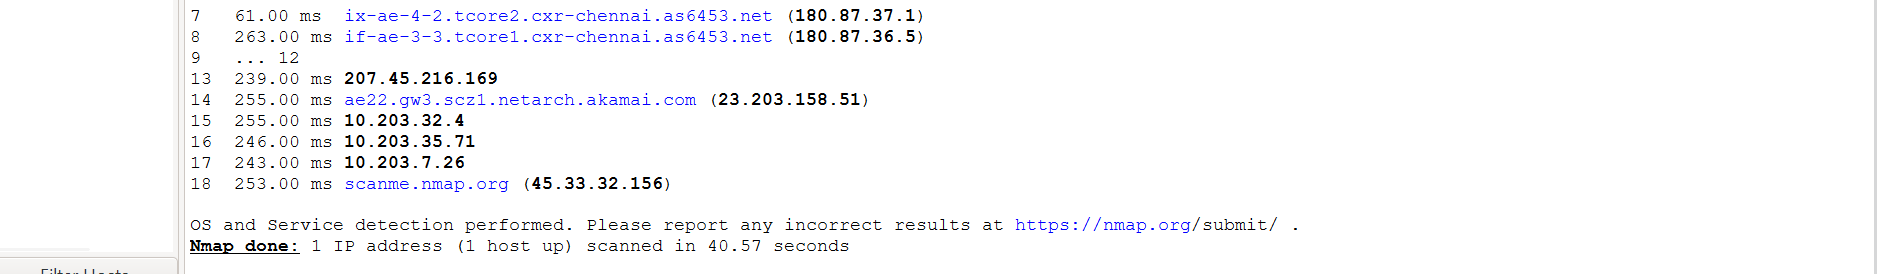

**3. VirusTotal Findings**



*  The scanned IP/domain was analyzed using the VirusTotal API.
*  The detection summary returned the following results:
      1. Malicious: 0
      2. Suspicious: 0
      1. Harmless: 61
      2. Undetected: 32
      1. Timeout: 0
*  No security vendors flagged the IP/domain as malicious.
*  61 security engines classified it as harmless.
*  32 vendors did not detect any threat (undetected does not mean malicious).
*  No scanning errors or timeouts occurred.






In [13]:
import requests
TARGET = "scanme.nmap.org"
API_KEY = "64d4e960618d9cefcb018dc4aef6f59c96d38da22530531665fec56c772257de"
def check_domain(domain):
    url = f"https://www.virustotal.com/api/v3/domains/{domain}"
    headers = {"x-apikey": API_KEY}
    response = requests.get(url, headers=headers)
    if response.status_code == 200:
        data = response.json()
        stats = data["data"]["attributes"]["last_analysis_stats"]
        print("\n===== VirusTotal Detection Summary =====")
        print(f"Harmless  : {stats['harmless']}")
        print(f"Malicious : {stats['malicious']}")
        print(f"Suspicious: {stats['suspicious']}")
        print(f"Undetected: {stats['undetected']}")
        print(f"Timeout   : {stats['timeout']}")
    else:
        print("Error:", response.status_code)
        print(response.text)
check_domain(TARGET)


===== VirusTotal Detection Summary =====
Harmless  : 61
Malicious : 0
Suspicious: 0
Undetected: 32
Timeout   : 0


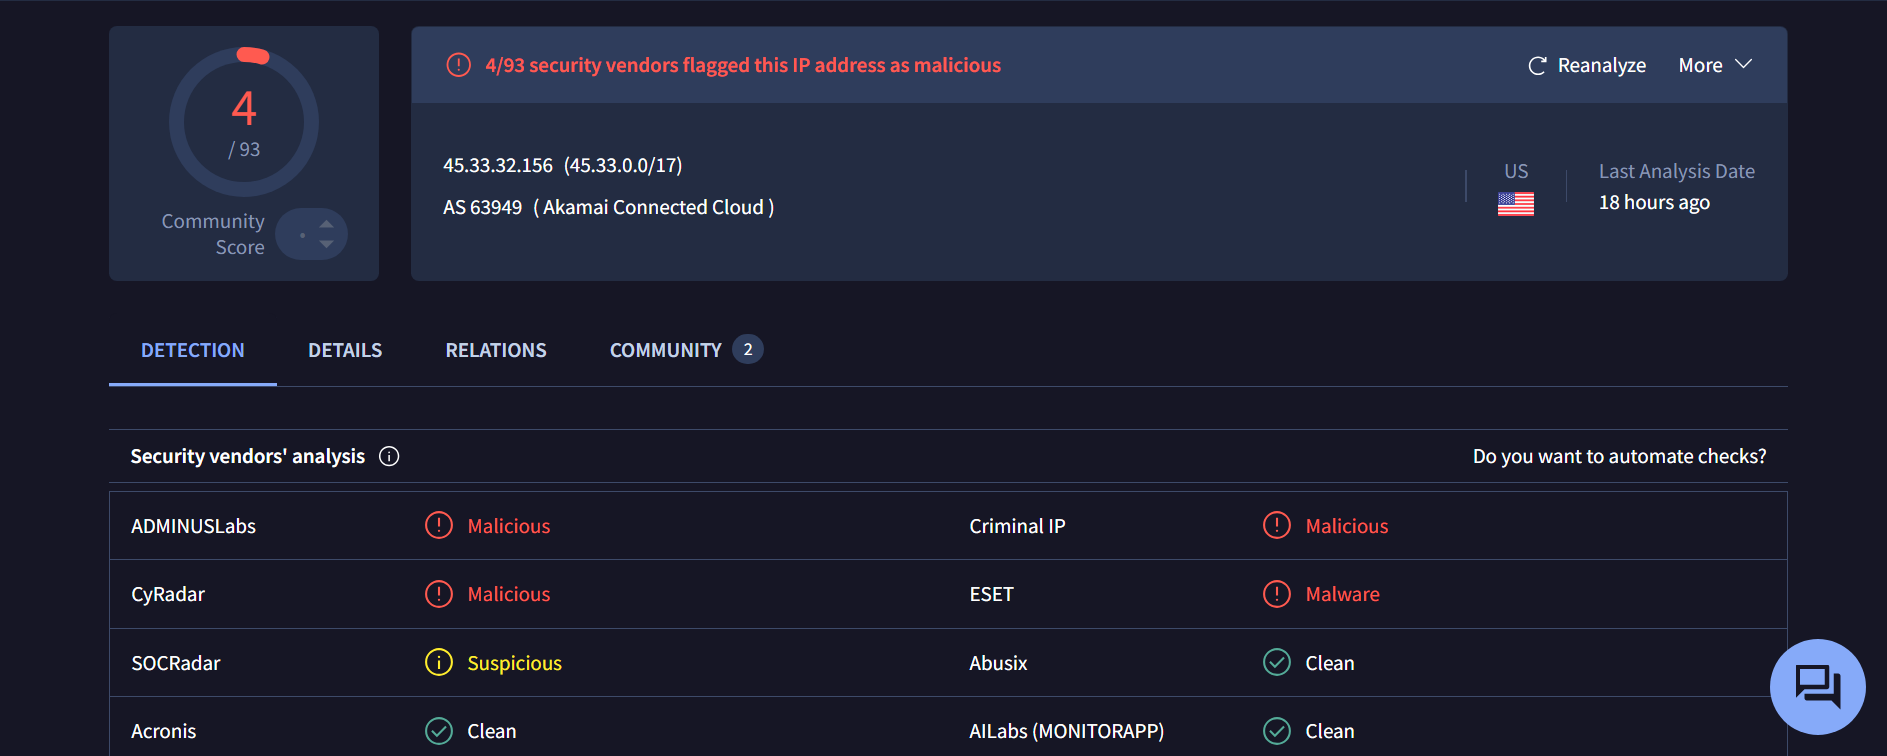

**4. Port & Service Analysis**

*  The Nmap scan identified multiple open TCP ports on the target system.
*  Each open port represents an exposed service that can potentially be accessed remotely.
*  Port 22 (SSH) is open and used for secure remote login.
     1. SSH allows administrative access to the system.
     2. If weak credentials are used, it may be vulnerable to brute-force attacks.
*  Port 80 (HTTP) is open and running a web server service.
     1. This allows users to access the website over the internet.
     2. Web servers can be vulnerable to attacks like XSS, SQL Injection, or directory traversal if not properly secured.
*  Port 443 (HTTPS) is open and provides secure encrypted web communication.
     1. HTTPS ensures data confidentiality using SSL/TLS encryption.
     2. Misconfigured SSL certificates may expose security weaknesses.


In [9]:
def analyze_ports(port):
    port_meanings = {
        22: "SSH – Remote secure login. Risk: brute-force, outdated version.",
        80: "HTTP – Web server. Risk: web vulnerabilities.",
        25: "SMTP – Email server. Risk: spam relay.",
        445: "SMB – Windows file sharing. Risk: ransomware exploitation."
    }
    if port in port_meanings:
        return port_meanings[port]
    else:
        return "Unknown or custom service. Needs investigation."
if __name__ == "__main__":
    test_ports = [22, 80, 9929, 31337]
    for p in test_ports:
        print(f"Port {p}: {analyze_ports(p)}")

Port 22: SSH – Remote secure login. Risk: brute-force, outdated version.
Port 80: HTTP – Web server. Risk: web vulnerabilities.
Port 9929: Unknown or custom service. Needs investigation.
Port 31337: Unknown or custom service. Needs investigation.


**5. Vulnerability Reasoning**

*   The Nmap scan identified open ports such as SSH (22), HTTP (80), and HTTPS (443).
*   Open ports increase the attack surface of the system because they allow external connections.
*   The SSH service (Port 22) could be vulnerable if:
     1. Weak passwords are used
     2. Default credentials are not changed
*   The HTTP service (Port 80) may be vulnerable to:
     1.   Cross-Site Scripting (XSS)
     2.   SQL Injection
*   The HTTPS service (Port 443) could face risks if:
     1. SSL/TLS certificates are expired or misconfigured
     2. Weak encryption protocols are enabled



In [10]:
def check_version_risk(product, version):
    if "OpenSSH" in product:
        print("Check OpenSSH version against known CVEs.")
    if "Apache" in product:
        print("Older Apache versions may contain remote code execution vulnerabilities.")
    if not product:
        print("Unknown service. Requires deeper inspection.")
if __name__ == "__main__":
    check_version_risk("OpenSSH", "6.6.1p1")
    check_version_risk("Apache httpd", "2.4.7")

Check OpenSSH version against known CVEs.
Older Apache versions may contain remote code execution vulnerabilities.


**6. Conclusion**


*   We scanned the target system using Nmap and VirusTotal.
*   The scan showed that some ports like SSH and web services are open.
*   The services running on those ports were identified.
*   No serious vulnerabilities were found during the scan.
*   VirusTotal did not report the target as malicious or suspicious.
*   Overall, the system appears safe at the time of scanning.
*   However, open ports should always be monitored to avoid future risks.






